## 1.1 Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1.2 Load the Data

In [2]:
# Load data
df = pd.read_csv('../data/aqi_data.csv')
# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (9135, 9)

First 5 rows:
         Date       City       PM2.5        PM10        NO2        SO2  \
0  2019-01-01      Delhi  106.901425  158.969494  55.715328  22.615149   
1  2019-01-01     Mumbai  139.376384  216.738924  38.957884  17.712800   
2  2019-01-01  Bangalore   99.258868  129.755500  20.126233  12.188562   
3  2019-01-01    Kolkata   64.759278   83.015880  67.984732  13.871118   
4  2019-01-01    Chennai   75.668518  114.612003  28.735096  16.878490   

         CO         O3         AQI  
0  1.129754  32.658630  128.281710  
1  1.060975  30.342702  173.391139  
2  0.896151  38.142473  119.110642  
3  1.220258  20.752518  101.977097  
4  1.019808  32.083063   91.689603  

Data Types:
Date      object
City      object
PM2.5    float64
PM10     float64
NO2      float64
SO2      float64
CO       float64
O3       float64
AQI      float64
dtype: object

Basic Statistics:
             PM2.5         PM10          NO2          SO2           CO  \
count  9135.000000  

## 1.3 Initial Data Inspection 

In [3]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unique values in categorical columns
print("\nUnique Cities:", df['City'].nunique())
print("Cities:", df['City'].unique())

# Date range
df['Date'] = pd.to_datetime(df['Date'])
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max()- df['Date'].min()).days}")


Missing Values:
Date     0
City     0
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
AQI      0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Unique Cities: 5
Cities: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Chennai']

Date Range: 2019-01-01 00:00:00 to 2024-01-01 00:00:00
Total Days: 1826


## 2 Exploratory Data Analysis (EDA)
### 2.1 Distribution od Taeget Variable (AQI)

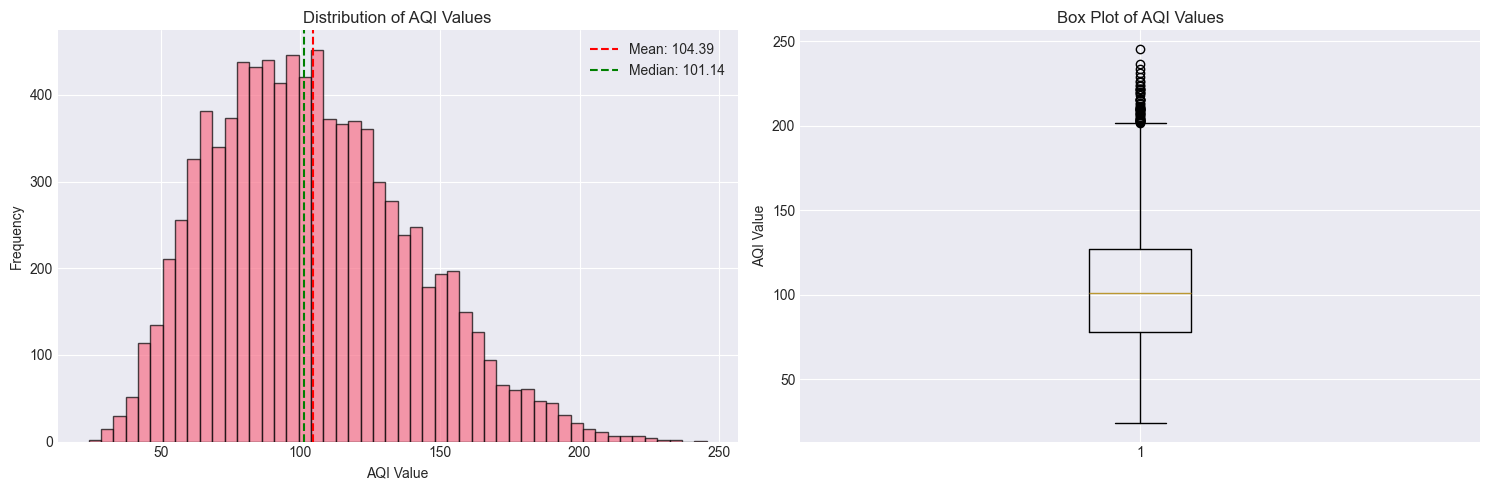

AQI Statistics:
Mean: 104.39
Median: 101.14
Std: 35.28
Min: 24.17
Max: 245.44


In [14]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['AQI'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of AQI Values')
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--', label=f'Mean: {df["AQI"].mean():.2f}')
axes[0].axvline(df['AQI'].median(), color='green', linestyle='--', label=f'Median: {df["AQI"].median():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['AQI'])
axes[1].set_ylabel('AQI Value')
axes[1].set_title('Box Plot of AQI Values')

plt.tight_layout()
plt.savefig('visualization', dpi=300, bbox_inches='tight')
plt.show()

print(f"AQI Statistics:")
print(f"Mean: {df['AQI'].mean():.2f}")
print(f"Median: {df['AQI'].median():.2f}")
print(f"Std: {df['AQI'].std():.2f}")
print(f"Min: {df['AQI'].min():.2f}")
print(f"Max: {df['AQI'].max():.2f}")

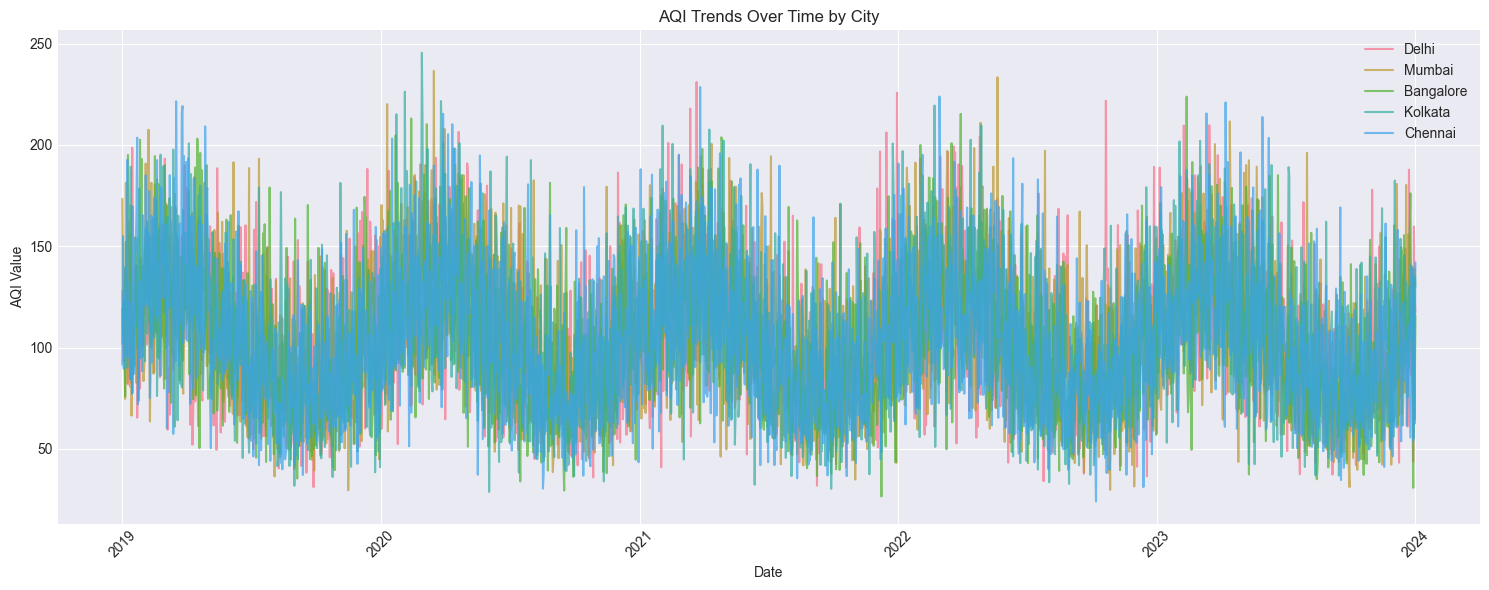

In [13]:
# AQI over time
plt.figure(figsize=(15, 6))
for city in df['City'].unique():
    city_data = df[df['City'] == city]
    plt.plot(city_data['Date'], city_data['AQI'], label=city, alpha=0.7)

plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.title('AQI Trends Over Time by City')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualization', dpi=300, bbox_inches='tight')
plt.show()